### 3.2 BERTopic model

In [ ]:
comp = 4
neigh = 19
min_size = 19
min_dist = 0.3


umap_model = umap.UMAP(
    n_neighbors=neigh,
    n_components=comp,
    min_dist=min_dist,
    metric='cosine',
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=min_size,
    metric='euclidean',
    cluster_selection_method='eom',
    min_samples=None
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    verbose=False,
    # calculate_probabilities=True,
    nr_topics=None
    )

topics, probs = topic_model.fit_transform(docs, emb)

In [65]:
for topic_id in topic_model.get_topic_info()["Topic"]:
    
    words = topic_model.get_topic(topic_id)
    words_str = " | ".join([word for word, _ in words])
    
    print(f"\n🧠 Topic {topic_id}")
    print(f"{words_str}")


🧠 Topic -1
upppa | atlantiques | bru | quiconqu | battre | pyrenee | porc | connaissent | environne | tal

🧠 Topic 0
majorit | communiste | falloir | homme | prsident | rpublique | changement | monsieur | donner | 14

🧠 Topic 1
accepter | triage | illusion | sortir | financier | production | dtruire | technologie | temps | celer

🧠 Topic 2
conviction | suppression | liste | redressement | fiscalist | lepen | payent | 4400000 | antisocialiste | absent

🧠 Topic 3
engager | degr | pourcent | chmeur | doubler | comptitivit | production | aller | million | 1992

🧠 Topic 4
lcr | travailleur | unit | revendication | patron | falloir | giscard | communiste | prendre | ministre

🧠 Topic 5
conviction | liste | suppression | penscience | fiscalist | 4400000 | gard | octroi | hgmonie | maternel


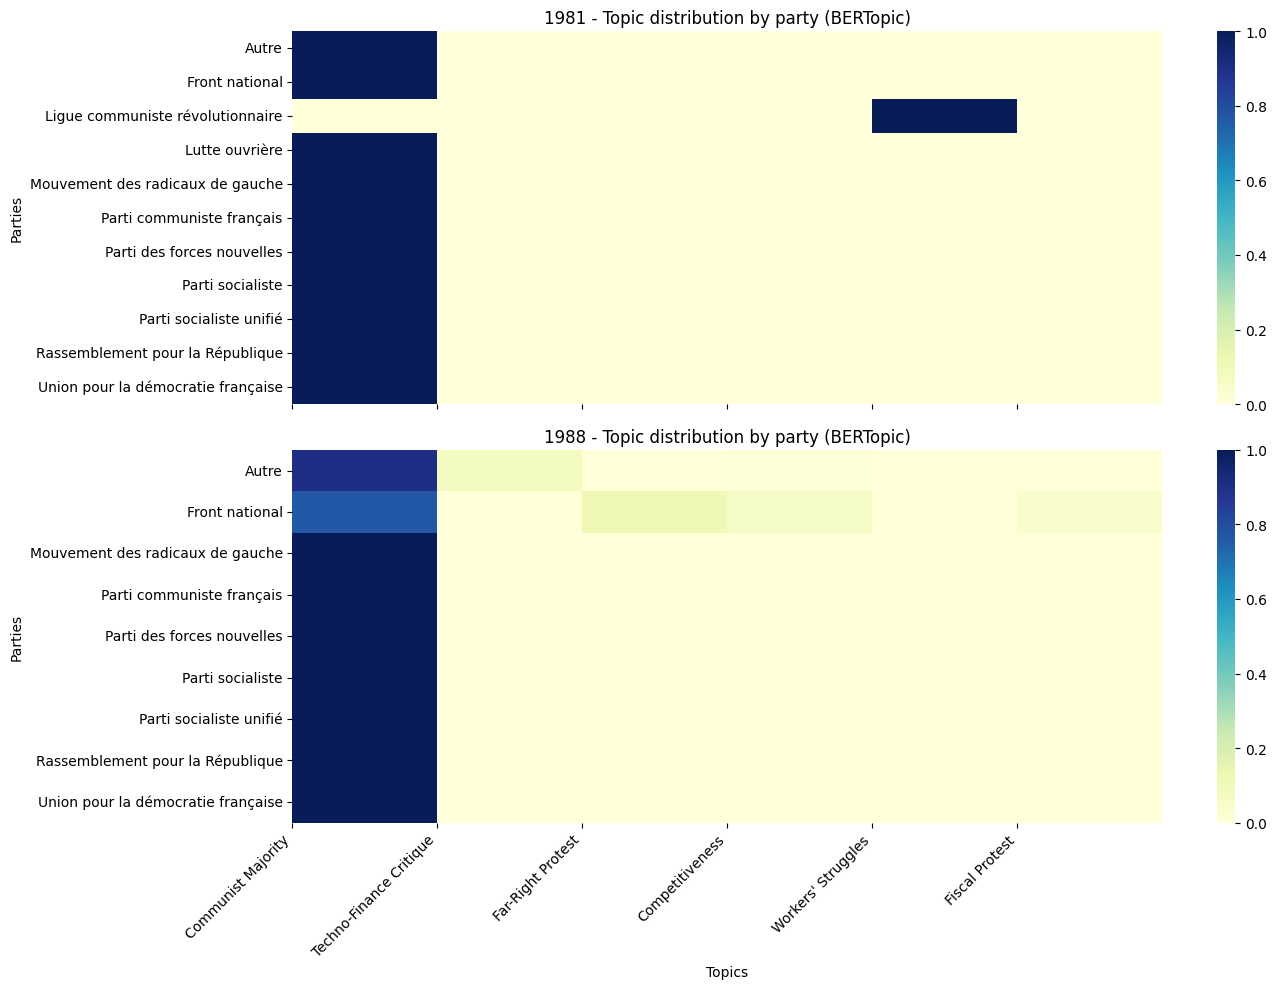

In [ ]:
# =========================
# DATAFRAME
# =========================
df2 = pd.DataFrame({
    "topic": topics,
    "parti": df["parti"],
    "annee": df["year"]
})

# enlever outliers
df2 = df2[df2["topic"] != -1]

# =========================
# DISTRIBUTION parti → topics
# =========================
counts = df2.groupby(["annee", "parti", "topic"]).size()

dist = counts.unstack(fill_value=0)

# ✅ NORMALISATION PAR PARTI (ligne = 1)
dist_norm = dist.div(dist.sum(axis=1), axis=0)

dist_81 = dist_norm.loc[1981]
dist_88 = dist_norm.loc[1988]

# =========================
# TITRES DES TOPICS
# =========================
topic_titles = [
    "Communist Majority",
    "Techno-Finance Critique",
    "Far-Right Protest",
    "Competitiveness",
    "Workers' Struggles",
    "Fiscal Protest"
    # ⚠️ adapte à ton nombre réel de topics
]

# =========================
# HEATMAPS
# =========================
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 1981
sns.heatmap(dist_81, cmap="YlGnBu", ax=axes[0])
axes[0].set_title("1981 - Topic distribution by party (BERTopic)")
axes[0].set_ylabel("Parties")
axes[0].set_xlabel(None)

# 1988
sns.heatmap(dist_88, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("1988 - Topic distribution by party (BERTopic)")
axes[1].set_ylabel("Parties")
axes[1].set_xlabel("Topics")

# ✅ labels propres
axes[1].set_xticks(np.arange(len(topic_titles)))
axes[1].set_xticklabels(topic_titles, rotation=45, ha="right")

plt.tight_layout()
plt.show()